# <span style="color:green"> Script (from G.N) for testing all automatic thresholding methods in 3Dslicer to choose one before going to pipeline

# Load libraries

In [1]:
from pathlib import Path
import os
import slicer
import matplotlib.pyplot as plt
import pandas as pd
import pyslicer as ps
import numpy as np
import vtk.util.numpy_support

# Papermill parameters to be changed

In [5]:
# Specify the directory of microCT files (first .jpg file)
nrrd_file = "primitive_scaffold/primitive_0000_high-quality.nrrd"

# Specify the Region: Specify left, mid, right, full, ...
side = 'full'

# 1. Preparing directories

In [6]:
# Specify the parent path
path = Path(nrrd_file)
folder_path = path.parent.absolute()


# Specify the directory of Specifications file 
Specifications_file_path = os.path.join(folder_path, "User_Specifications.txt")

# 2. Prepare 3dSlicer and Import CT data

In [7]:
# Load the NRRD file
masterVolumeNode = slicer.util.loadVolume(nrrd_file)

# Create segmentationNode

## Create segmentation-related nodes

Create segmentation node

In [8]:
segmentationNode = ps.segmentation.segmentationNode(name='Segmentation')

Create temporary segment editor to get access to effects

In [9]:
segmentEditorWidget, segmentEditorNode = ps.segmentation.segmentEditorWidget(segmentationNode = segmentationNode, 
                                                                             masterVolumeNode = masterVolumeNode)

# Thresholding

## Check different automatic segmentation algorithms

The first time you analyze an image/channel. Go to the ```Segment Editor```, add a new segment and choose the thresholding method. There you test different automatic thresholding technique and choose the one working best. For later analysis, you can just copy the thresholding values in the ```segments_greyvalues``` object at the beginning of this notebook.

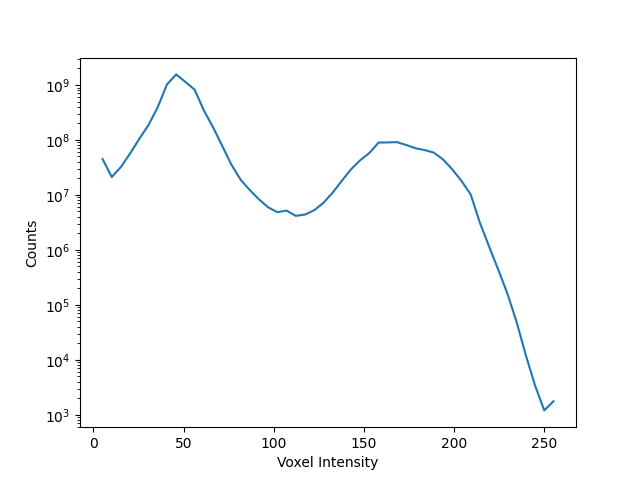

In [10]:
ps.volume.plot_histogram(masterVolumeNode, yscale='log')

In [11]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/1/intensities_1.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

Get automatic thresholding values, as indicated in [this script](https://github.com/jzeyl/3D-Slicer-Scripts/blob/db51967cc642837e8bae0fea1585a95074d8420b/load_dicom_modified_otsu.py#L56)

In [12]:
methods = [
            'HUANG',
            'INTERMODES',
            'ISO_DATA',
            'KITTLER_ILLINGWORTH',
            'LI',
            'MAXIMUM_ENTROPY',
            'MOMENTS',
            'OTSU',
            'RENYI_ENTROPY',
            'SHANBHAG',
            'TRIANGLE',
            'YEN'
            ]

thresholds = dict.fromkeys(methods, None)
thresholds

{'HUANG': None,
 'INTERMODES': None,
 'ISO_DATA': None,
 'KITTLER_ILLINGWORTH': None,
 'LI': None,
 'MAXIMUM_ENTROPY': None,
 'MOMENTS': None,
 'OTSU': None,
 'RENYI_ENTROPY': None,
 'SHANBHAG': None,
 'TRIANGLE': None,
 'YEN': None}

Otsu thresholding

OTSU threshold: 107.59493255615234


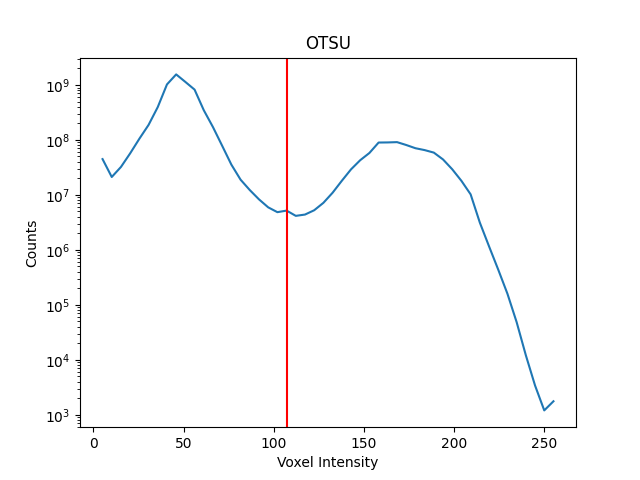

In [13]:
method = 'OTSU'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masterVolumeNode)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masterVolumeNode, threshold = threshold, title = method, yscale='log')

In [14]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/1/OTSU_1.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

Huang thresholding

HUANG threshold: 101.61743545532227


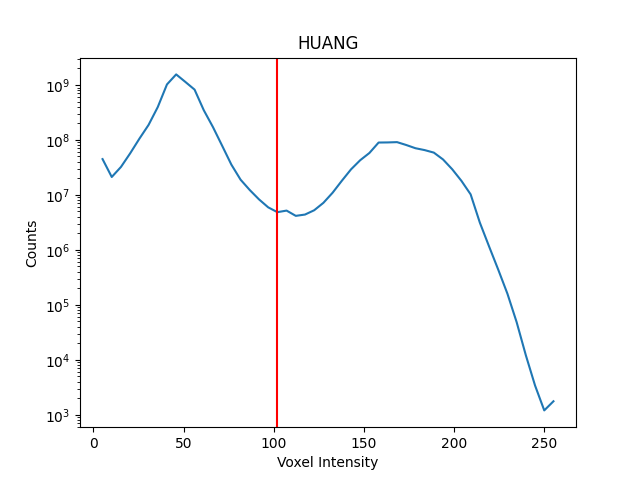

In [15]:
method = 'HUANG'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masterVolumeNode)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masterVolumeNode, threshold = threshold, title = method, yscale='log')

In [16]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/1/HUANG_1.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

IsoData thresholding

ISO_DATA threshold: 109.58743286132812


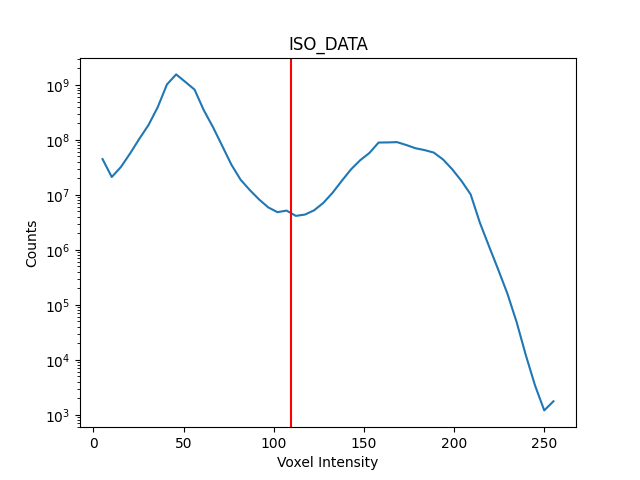

In [17]:
method = 'ISO_DATA'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masterVolumeNode)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masterVolumeNode, threshold = threshold, title = method, yscale='log')

In [18]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/1/ISO_DATA_1.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

MAXIMUM_ENTROPY thresholding

MAXIMUM_ENTROPY threshold: 253.0473419189453


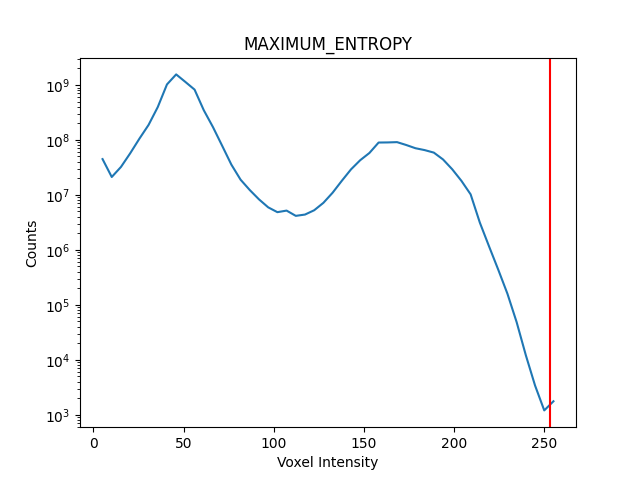

In [19]:
method = 'MAXIMUM_ENTROPY'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masterVolumeNode)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masterVolumeNode, threshold = threshold, title = method, yscale='log')

In [20]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/1/MAXIMUM_ENTROPY_1.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

MOMENTS thresholding

MOMENTS threshold: 69.73745727539062


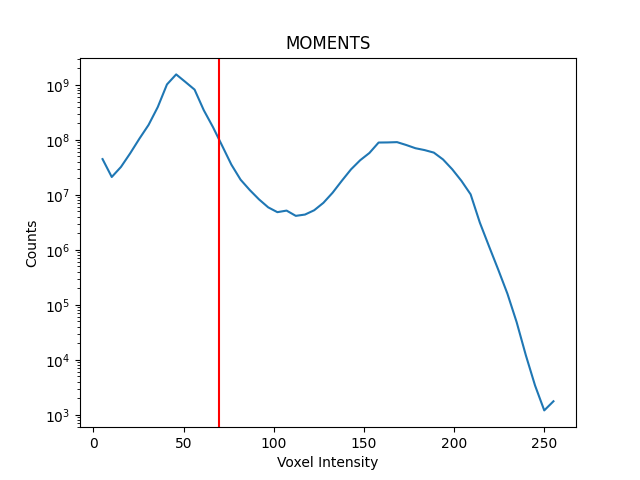

In [21]:
method = 'MOMENTS'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masterVolumeNode)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masterVolumeNode, threshold = threshold, title = method, yscale='log')

In [22]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/1/MOMENTS_1.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

INTERMODES thresholding

INTERMODES threshold: 101.61743545532227


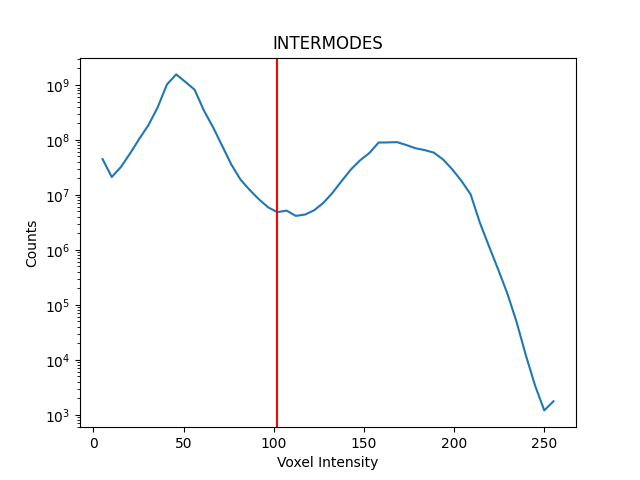

In [23]:
method = 'INTERMODES'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masterVolumeNode)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masterVolumeNode, threshold = threshold, title = method, yscale='log')

In [24]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/1/INTERMODES_1.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

LI threshold: 2.61e-321


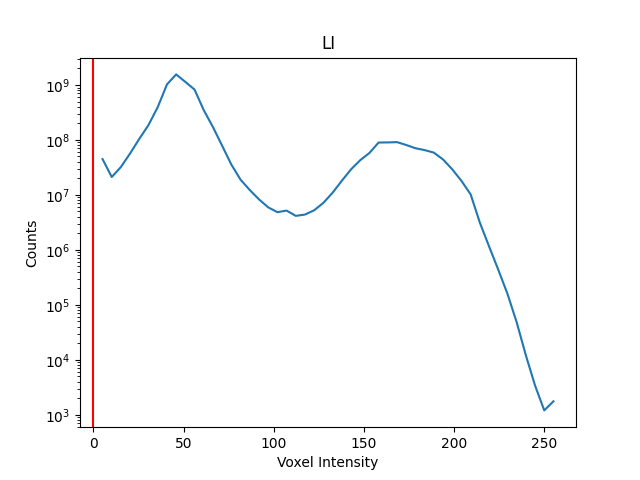

In [25]:
method = 'LI'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masterVolumeNode)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masterVolumeNode, threshold = threshold, title = method, yscale='log')

In [26]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/1/LI_1.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

KITTLER_ILLINGWORTH threshold: 85.67744445800781


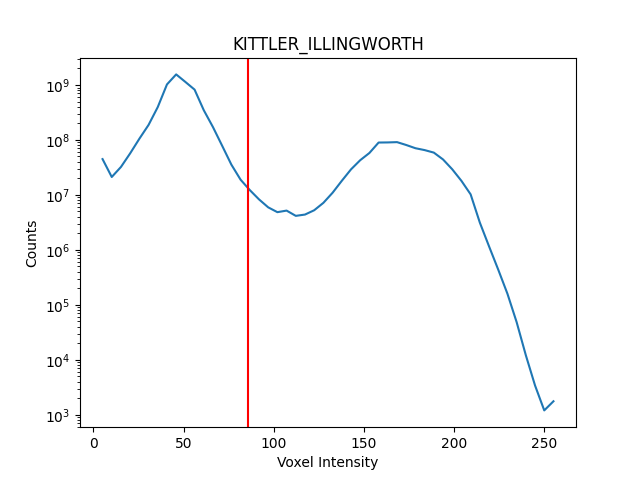

In [27]:
method = 'KITTLER_ILLINGWORTH'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masterVolumeNode)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masterVolumeNode, threshold = threshold, title = method, yscale='log')

In [28]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/1/KITTLER_ILLINGWORTH_1.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

RENYI_ENTROPY threshold: 65.7524585723877


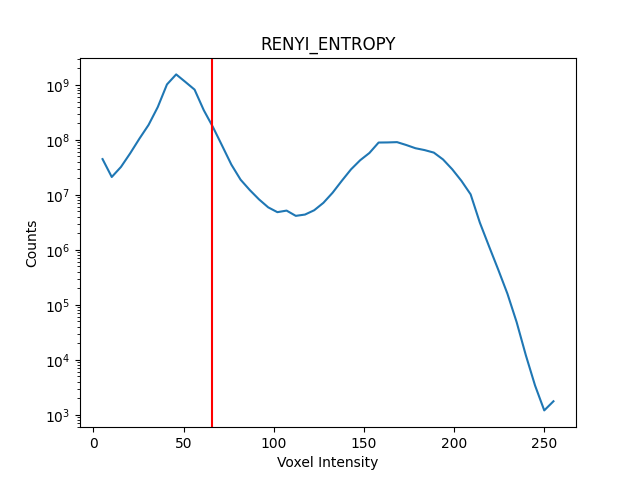

In [29]:
method = 'RENYI_ENTROPY'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masterVolumeNode)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masterVolumeNode, threshold = threshold, title = method, yscale='log')

In [30]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/1/RENYI_ENTROPY_1.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

SHANBHAG threshold: 253.0473419189453


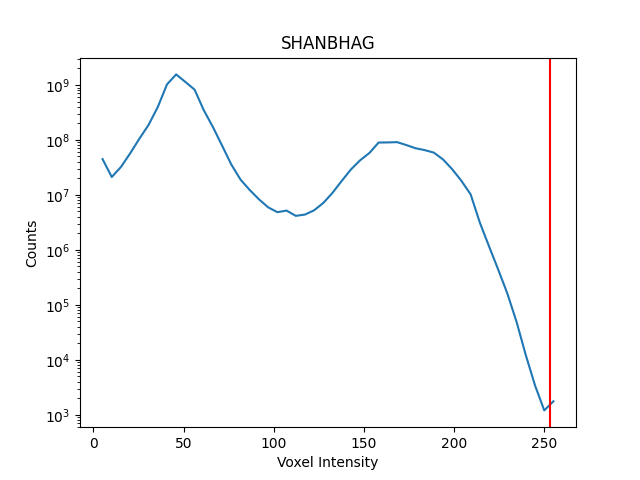

In [31]:
method = 'SHANBHAG'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masterVolumeNode)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masterVolumeNode, threshold = threshold, title = method, yscale='log')

In [32]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/1/SHANBHAG_1.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

YEN threshold: 249.06233978271484


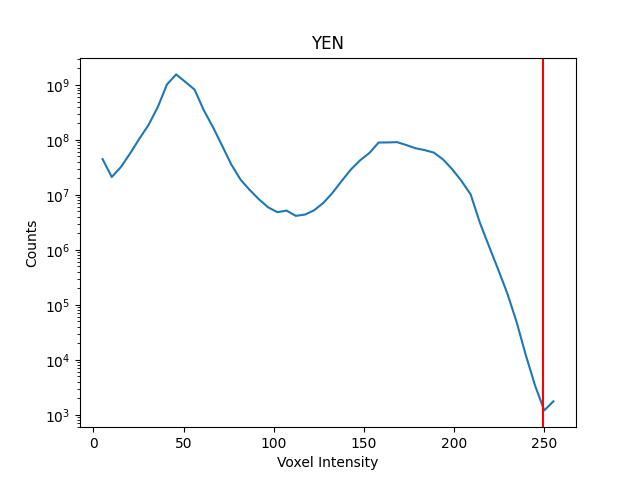

In [33]:
method = 'YEN'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masterVolumeNode)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masterVolumeNode, threshold = threshold, title = method, yscale='log')

In [34]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/1/YEN_1.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

TRIANGLE threshold: 73.72245407104492


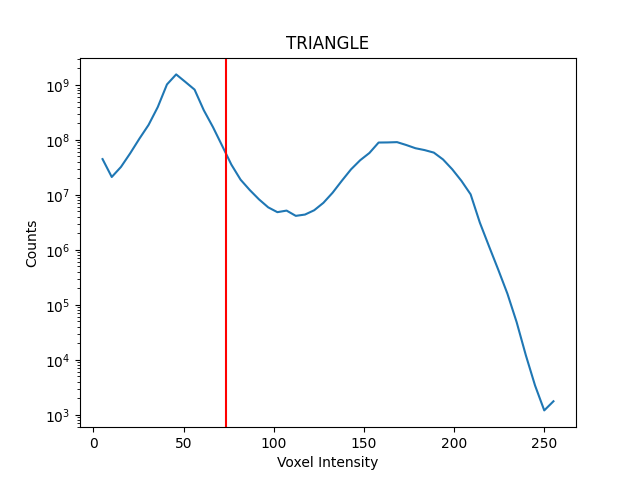

In [35]:
method = 'TRIANGLE'

threshold = ps.segmentation.compute_threshold(method = method, volumeNode = masterVolumeNode)

thresholds[method.upper()] = threshold

print(method + " threshold: " + str(threshold))
ps.volume.plot_histogram(masterVolumeNode, threshold = threshold, title = method, yscale='log')

In [36]:
# Save the plot as an image file
histo_out = folder_path / 'thresholding/1/TRIANGLE_1.png'
histo_out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(histo_out)

## Select thresholding values

In [37]:
thresholds_1 = thresholds
thresholds_1

{'HUANG': 101.61743545532227,
 'INTERMODES': 101.61743545532227,
 'ISO_DATA': 109.58743286132812,
 'KITTLER_ILLINGWORTH': 85.67744445800781,
 'LI': 2.61e-321,
 'MAXIMUM_ENTROPY': 253.0473419189453,
 'MOMENTS': 69.73745727539062,
 'OTSU': 107.59493255615234,
 'RENYI_ENTROPY': 65.7524585723877,
 'SHANBHAG': 253.0473419189453,
 'TRIANGLE': 73.72245407104492,
 'YEN': 249.06233978271484}

## Save the data as txt file

In [38]:
output_file = folder_path / 'thresholding/automatic_thresholding.txt'
# Ensure the directory exists
output_file.parent.mkdir(parents=True, exist_ok=True)

# Write the content to the file
with open(output_file, 'w') as file:
    file.write(f"thresholds_1:\n{thresholds_1}\n")


In [39]:
# Define a list of 12 distinct colors
colors = [
    '#FF5733',  # Red-Orange
    '#33FF57',  # Green
    '#3357FF',  # Blue
    '#FF33B5',  # Pink
    '#B533FF',  # Purple
    '#33FFF3',  # Cyan
    '#FFAF33',  # Orange
    '#9AFF33',  # Lime
    '#FF3333',  # Red
    '#5733FF',  # Indigo
    '#FFDD33',  # Yellow
    '#FF33F1',  # Magenta
]

# Plotting the histogram
ps.volume.plot_histogram(masterVolumeNode, yscale='log')

# Getting the current axis object
ax = plt.gca()

# Getting the min and max values of the x-axis (intensity values)
min_value, max_value = ax.get_xlim()

# Adding vertical lines for each threshold with distinct colors
for index, (method, threshold) in enumerate(thresholds_1.items()):
    if min_value <= threshold <= max_value:
        plt.axvline(x=threshold, label=f'{method}: {threshold:.2f}', linestyle='--', color=colors[index], alpha=0.7)

# Customizing the plot
plt.xlabel('Intensity Value')
plt.ylabel('Frequency (Log Scale)')
plt.title('Histogram with Thresholds')
plt.legend(loc='upper right', fontsize='small')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)

# Save the plot
plt.savefig(folder_path / 'thresholding/all1.png')
